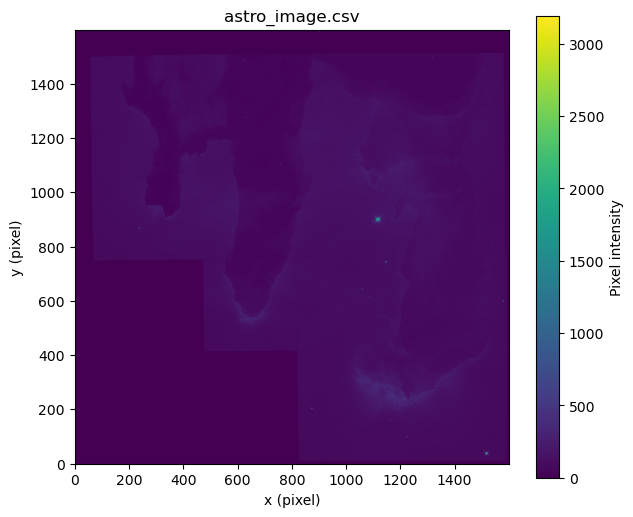

In [4]:
import numpy as np
import matplotlib.pyplot as plt
img = np.loadtxt("astro_image.csv")

plt.figure(figsize=(7,6))
im = plt.imshow(img, origin="lower")
plt.colorbar(im, label="Pixel intensity")
plt.title("astro_image.csv")
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")
plt.show()


In [6]:
import pandas as pd
df = pd.read_csv("ramen-ratings.csv")
df.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [11]:
# 1) The column names are : Review #, Brand, Variety, Style, Country, Stars, Top Ten.
df.columns.tolist()

['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']

In [12]:
# 2) The 27th entry is Pack
df.loc[26, "Style"]

'Pack'

In [14]:
# 3) There are total of 355 brands
df["Brand"].nunique()

355

In [15]:
# 4) 
df_sorted = df.sort_values(by="Brand", ascending=True)
df_sorted.head(10)

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
947,1633,A-One,Mi Ly Instant Noodles Mi Bo Beef Flavor,Cup,Vietnam,3.5,NaN
1016,1564,A-One,Mì Ly Instant Noodles Mì Thịt Xào Pork Flavor,Cup,Vietnam,3,NaN
1289,1291,A-One,Mì Ly Instant Noodles Mì Tôm Shrimp Flavor,Cup,Vietnam,3.25,NaN
1252,1328,A-Sha Dry Noodle,Hello Kitty La Wei (Spicy Flavor),Pack,Taiwan,3.75,NaN
424,2156,A-Sha Dry Noodle,Chow Mein Oyster Sauce BBQ Flavor,Tray,Taiwan,2,NaN


In [17]:
# 5) 49 brands are made in USA
usa_brand_count = df.loc[df["Country"] == "USA", "Brand"].nunique()
usa_brand_count

49

In [19]:
# 6) 27 brands are made pack-style Ramen 
usa_pack_brand_count = df.loc[
    (df["Country"] == "USA") & (df["Style"] == "Pack"),
    "Brand"
].nunique()
usa_pack_brand_count

27

In [24]:
# 7)  top 10? (I think)
top10_brands = (
    df.loc[df["Top Ten"].notna(), "Brand"]
    .dropna()
    .unique()
)
top10_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table

fname = "global_CCl4_MM.dat"
tbl = Table.read(fname, format="ascii", guess=True)
df_all = tbl.to_pandas()

print("Astropy columns:", list(df_all.columns))

year_col = "CCl4ottoyr"
mon_col  = "CCl4ottomon"
mean_col = "CCl4ottoGLm"
sd_col   = "CCl4ottoGLsd"

df = df_all[[year_col, mon_col, mean_col, sd_col]].copy()
df.columns = ["year", "month", "mean", "sd"]

for c in ["year", "month", "mean", "sd"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["year", "month", "mean", "sd"])
df = df[df["sd"] > 0]

df["date"] = df["year"] + (df["month"] - 1) / 12.0

x = df["date"].to_numpy(float)
y = df["mean"].to_numpy(float)
sigma = df["sd"].to_numpy(float)

print("N points =", len(df))
df.head()


Astropy columns: ['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd', 'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd']
N points = 280


,year,month,mean,sd,date
3,1996,4,104.144,0.155,1996.250000
4,1996,5,103.893,0.174,1996.333333
5,1996,6,104.207,0.191,1996.416667
6,1996,7,104.136,0.147,1996.500000
7,1996,8,103.836,0.161,1996.583333


LINEAR model: y = m*x + b
m = -1.154410 ± 0.001281
b = 2409.219 ± 2.572
chi^2 = 1233.44
reduced chi^2 = 4.421

QUADRATIC model: y = a*x^2 + b*x + c
a = -1.647103e-03, b = 5.459987, c = -4231.214
chi^2 = 1168.79
reduced chi^2 = 4.189


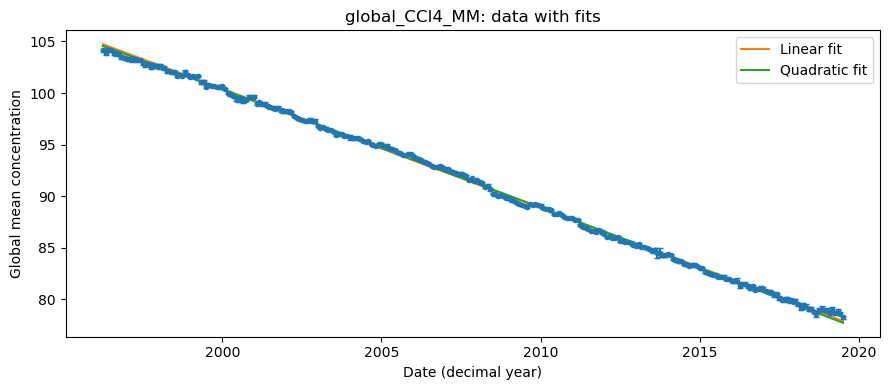

In [38]:
def weighted_polyfit(x, y, sigma, deg):

    X = np.vander(x, deg + 1)
    w = 1.0 / (sigma**2)

    XTWX = X.T @ (w[:, None] * X)
    XTWy = X.T @ (w * y)

    coeffs = np.linalg.solve(XTWX, XTWy)
    cov = np.linalg.inv(XTWX)
    return coeffs, cov

def chi2_stats(x, y, sigma, coeffs):
    yfit = np.polyval(coeffs, x)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    N = len(x)
    red_N1 = chi2 / (N - 1)
    return yfit, chi2, red_N1

coeff1, cov1 = weighted_polyfit(x, y, sigma, deg=1)
coeff2, cov2 = weighted_polyfit(x, y, sigma, deg=2)

yfit1, chi2_1, red1 = chi2_stats(x, y, sigma, coeff1)
yfit2, chi2_2, red2 = chi2_stats(x, y, sigma, coeff2)

m, b = coeff1
m_err, b_err = np.sqrt(np.diag(cov1))

print("LINEAR model: y = m*x + b")
print(f"m = {m:.6f} ± {m_err:.6f}")
print(f"b = {b:.3f} ± {b_err:.3f}")
print(f"chi^2 = {chi2_1:.2f}")
print(f"reduced chi^2 = {red1:.3f}")

a2, b2, c2 = coeff2
print("\nQUADRATIC model: y = a*x^2 + b*x + c")
print(f"a = {a2:.6e}, b = {b2:.6f}, c = {c2:.3f}")
print(f"chi^2 = {chi2_2:.2f}")
print(f"reduced chi^2 = {red2:.3f}")

xx = np.linspace(x.min(), x.max(), 600)
plt.figure(figsize=(9,4))
plt.errorbar(x, y, yerr=sigma, fmt=".", capsize=2)
plt.plot(xx, np.polyval(coeff1, xx), label="Linear fit")
plt.plot(xx, np.polyval(coeff2, xx), label="Quadratic fit")
plt.xlabel("Date (decimal year)")
plt.ylabel("Global mean concentration")
plt.title("global_CCl4_MM: data with fits")
plt.legend()
plt.tight_layout()
plt.show()

# The value of reduced chi squares is 4 , is quite big . So I would say the fit is not capturing structure, thus is a bad fit?